# CEH GEAR Monthly Rainfall: NetCDF via R

**Launch this notebook:**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/NERC-CEH/fdri-gridded-notebooks/blob/main/gear_netcdf_r.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/NERC-CEH/fdri-gridded-notebooks/HEAD?labpath=gear_netcdf_r.ipynb)

> **Google Colab:** If running in Google Colab, you will need to switch to an R runtime. Click the "Runtime" menu in the menu bar at the top of the screen, select Change runtime type, select R from the 'Runtime type' drop down box, you can leave the rest the same.

---

## What this notebook does

This notebook explores **CEH-GEAR-1hr** (Gridded Estimates of Areal Rainfall — Hourly), a gridded rainfall dataset for Great Britain produced as part of the [FDRI (Floods and Droughts Research Infrastructure)](https://fdri.org.uk) project.

Simple examples are shown for exploring and working with the dataset, which can be generalised to any gridded dataset stored in NetCDF format.

A key limitation of working with NetCDF is that data files have to be downloaded to your machine - or wherever you are running the notebook - before you can work with them. This is why we also provide a [version](https://colab.research.google.com/github/NERC-CEH/fdri-gridded-notebooks/blob/main/gear_zarr_R.ipynb) of this notebook that uses the Zarr format instead, which removes the limitation and allows you to work with multi-terabyte datasets without worrying about having to download it all.

**We will:**
1. Show how to open a dataset stored in NetCDF format
2. Show how to extract and plot a time series at a single location, and demonstrate the limitations of NetCDF for this
3. Show how to plot a map of rainfall at a single time step

**Data store:**
The data is publicly available via the EIDC catalogue: https://catalogue.ceh.ac.uk/documents/fc9423d6-3d54-467f-bb2b-fc7357a3941f

---

## 0. Setup

Install and load `ncdf4`. This takes ~1 minute on first run.

In [1]:
if (!requireNamespace("ncdf4", quietly = TRUE))
  install.packages("ncdf4", repos = "https://cloud.r-project.org", verbose = TRUE)

library(ncdf4)
cat("ncdf4 version:", as.character(packageVersion("ncdf4")), "\n")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

system (cmd0): /usr/lib/R/bin/R CMD INSTALL

foundpkgs: ncdf4, /tmp/RtmpAa7APG/downloaded_packages/ncdf4_1.24.tar.gz

files: /tmp/RtmpAa7APG/downloaded_packages/ncdf4_1.24.tar.gz

1): succeeded '/usr/lib/R/bin/R CMD INSTALL -l '/usr/local/lib/R/site-library' '/tmp/RtmpAa7APG/downloaded_packages/ncdf4_1.24.tar.gz''



ncdf4 version: 1.24 


---
## 1. Download the NetCDF file

To work with NetCDF data we have to download the files ourselves, to our local machines (desktops/laptops), or wherever this notebook is running. A dataset in NetCDF format is usually split up into several files, typically across the time dimension.

To see what files are available, go to the [catalogue web-page](https://catalogue.ceh.ac.uk/documents/fc9423d6-3d54-467f-bb2b-fc7357a3941f) for this dataset and click 'Download', then the Download button next to the 'Direct Access Files' option that appears from the left.

Looking at the filenames tells you that the dataset is split into monthly files across the time span it covers. Looking at the sizes in the 3rd column tells you that each file is at least 300MB. You can also see that there are a lot of files.
Each file contains a month's worth of hourly rainfall estimates across the UK.

We will therefore download only a single file of the data, obtaining the URL by right clicking on the file of interest (in this case for Jan 2000) and selecting 'Copy Link'. This link is used below to download the file:

> **Note:** The file is ~300 MB. The download will likely take a few seconds to minutes!

In [2]:
nc_url  <- paste0(
  "https://catalogue.ceh.ac.uk/datastore/eidchub/fc9423d6-3d54-467f-bb2b-fc7357a3941f/CEH-GEAR-1hr-v2_200001.nc"
)
nc_file <- "CEH-GEAR-1hr-v2_200001.nc"

if (!file.exists(nc_file)) {
  cat("Downloading file (~300 MB)...\n")
  download.file(nc_url, nc_file, mode = "wb", quiet = FALSE)
} else {
  cat("File already downloaded.\n")
}

cat(sprintf("File size: %.1f MB\n", file.size(nc_file) / 1e6))

File size: 378.4 MB


---
## 2. Open the file and inspect metadata

In [3]:
nc <- nc_open(nc_file)

# Print the full file summary — similar to ncdump -h
cat("=== FILE SUMMARY ===\n")
cat("Format   :", nc$format, "\n")
cat("Variables:", nc$nvars, "\n")
cat("Dims     :", nc$ndims, "\n")

[1] ">>>> WARNING <<<  attribute _FillValue is an 8-byte value, but R"
[1] "does not support this data type. I am returning a double precision"
[1] "floating point, but you must be aware that this could lose precision!"
=== FILE SUMMARY ===
Format   : NC_FORMAT_NETCDF4 
Variables: 9 
Dims     : 4 


### 2a. Global attributes (dataset-wide metadata)

In [8]:
cat("=== GLOBAL ATTRIBUTES ===\n")
gatts <- ncatt_get(nc, 0)
for (nm in names(gatts)) {
  val <- as.character(gatts[[nm]])
  cat(sprintf("  %-30s : %s\n", nm, val))
}

=== GLOBAL ATTRIBUTES ===
  institution                    : Newcastle University
  summary                        : The CEH-GEAR1hr-v2 dataset contains 1-km grids of hourly rainfall estimates for GB for the period 1990-2017. The gridded rainfall estimates are derived by applying the nearest neighbour interpolation method to hourly raingauge observations. These interpolated hourly estimates were then used to temporally disaggregate the daily CEH-GEAR dataset (https://doi.org/10.5285/33604ea0-c238-4488-813d-0ad9ab7c51ca). The dataset also contains, for each day, a grid containing, for each grid point, the distance between the grid point and the closest recording raingauge used in its interpolation.  When this distance is greater than 50 km, or there is 0mm rainfall recorded in the closest gauge the daily value is disaggregated using a design storm. The dataset therefore also contains for each day, a grid containing for each grid point a flag showing if the design storm was used. These g

### 2b. Variables

In [5]:
cat("=== VARIABLES ===\n")
for (v in nc$var) {
  dim_str <- paste(sapply(v$dim, function(d) d$name), collapse = " × ")
  units   <- ncatt_get(nc, v$name, "units")$value
  lname   <- ncatt_get(nc, v$name, "long_name")$value
  cat(sprintf("  %-30s [%s]\n", v$name, dim_str))
  if (!is.logical(units)) cat(sprintf("    units     : %s\n", units))
  if (!is.logical(lname)) cat(sprintf("    long_name : %s\n", lname))
}

=== VARIABLES ===
  x_bnds                         [bnds × x]
    units     : 0
    long_name : 0
  y_bnds                         [bnds × y]
    units     : 0
    long_name : 0
  lat                            [x × y]
    units     : degrees_north
    long_name : latitude
  lon                            [x × y]
    units     : degrees_east
    long_name : longitude
  time_bnds                      [bnds × time]
    units     : 0
    long_name : 0
  rainfall_amount                [x × y × time]
    units     : kg m-2
    long_name : Gridded estimates of hourly rainfall
  min_dist                       [x × y × time]
    units     : m
    long_name : Minimum distance
  stat_disag                     [x × y × time]
    units     : 
    long_name : Statistical disaggregation
  crs                            []
    units     : 0
    long_name : 0


### 2c. Dimensions

In [10]:
cat("=== DIMENSIONS ===\n")
for (dim in nc$dim) {
  cat(sprintf("  %-10s : %d values\n", dim$name, dim$len))
}

=== DIMENSIONS ===
  x          : 701 values
  y          : 1251 values
  time       : 744 values
  bnds       : 2 values


---
## 2d Read coordinate arrays

In [20]:
x    <- ncvar_get(nc, "x")     # easting, metres
y    <- ncvar_get(nc, "y")     # northing, metres
time <- ncvar_get(nc, "time")  # time values

# Decode time axis
time_units <- ncatt_get(nc, "time", "units")$value

# Parse "hours since YYYY-MM-DD" format
origin_str <- sub(".*since\\s+", "", time_units)
origin_dt  <- as.POSIXct(origin_str, tz = "UTC",
                format = ifelse(grepl(":", origin_str), "%Y-%m-%d %H:%M:%S", "%Y-%m-%d"))

# Determine units multiplier (hours → seconds; days → seconds; etc.)
unit_word  <- tolower(sub("\\s+since.*", "", time_units))
multiplier <- switch(unit_word,
  "hours"   = 3600,
  "days"    = 86400,
  "minutes" = 60,
  "seconds" = 1,
  3600  # default to hours
)

datetimes <- origin_dt + as.numeric(time) * multiplier

cat(sprintf("x (easting) : %d values, %.0f m to %.0f m  (%.0f m spacing)\n",
  length(x), min(x), max(x), x[2] - x[1]))
cat(sprintf("y (northing): %d values, %.0f m to %.0f m  (%.0f m spacing)\n",
  length(y), min(y), max(y), y[1] - y[2]))
cat(sprintf("Time        : %d steps, %s to %s\n",
  length(datetimes), min(datetimes), max(datetimes)))

x (easting) : 701 values, 0 m to 700000 m  (1000 m spacing)
y (northing): 1251 values, 0 m to 1250000 m  (1000 m spacing)
Time        : 744 steps, 2000-01-01 to 2000-01-31 23:00:00


---
## 3. Time series at a single location

We find the nearest grid cell to a target x/y coordinate, then read all the timesteps for this file.

**Key Point:** To plot different months we would have to download the relevant files of the dataset as we did in Section 1. If we wanted to plot multiple months we would have to download multiple large files, if not the whole dataset, which quickly gets unwieldy given the size of the dataset. For increased flexibility and ease-of-use, consider using the Zarr version of the dataset instead via [this notebook](https://colab.research.google.com/github/NERC-CEH/fdri-gridded-notebooks/blob/main/gear_zarr_R.ipynb).

Load the data:

In [22]:
# Target location in British National Grid coordinates (easting, northing in metres)
# Edinburgh ~ (325000, 673000)
target_x <- 325000
target_y <- 673000

# Find the nearest grid cell indices
i_x <- which.min(abs(x - target_x))
i_y <- which.min(abs(y - target_y))

cat(sprintf("Target  : x=%d, y=%d\n", target_x, target_y))
cat(sprintf("Nearest : x=%.0f (index %d), y=%.0f (index %d)\n",
  x[i_x], i_x, y[i_y], i_y))

# Read all time steps for this single grid cell
# start = [x_index, y_index, time_index_1], count = [1, 1, all_times]
ts_vals <- ncvar_get(
  nc, "rainfall_amount",
  start = c(i_x, i_y, 1),
  count = c(1, 1, length(time))
)

ts_df <- data.frame(date = datetimes, rainfall_mm = as.numeric(ts_vals))
print(ts_df)

Target  : x=325000, y=673000
Nearest : x=325000 (index 326), y=673000 (index 578)
                   date rainfall_mm
1   2000-01-01 00:00:00         0.0
2   2000-01-01 01:00:00         0.0
3   2000-01-01 02:00:00         0.0
4   2000-01-01 03:00:00         0.0
5   2000-01-01 04:00:00         0.0
6   2000-01-01 05:00:00         0.0
7   2000-01-01 06:00:00         0.0
8   2000-01-01 07:00:00         0.0
9   2000-01-01 08:00:00         0.0
10  2000-01-01 09:00:00         0.0
11  2000-01-01 10:00:00         0.0
12  2000-01-01 11:00:00         0.1
13  2000-01-01 12:00:00         0.0
14  2000-01-01 13:00:00         0.0
15  2000-01-01 14:00:00         0.0
16  2000-01-01 15:00:00         0.0
17  2000-01-01 16:00:00         0.0
18  2000-01-01 17:00:00         0.0
19  2000-01-01 18:00:00         0.0
20  2000-01-01 19:00:00         0.0
21  2000-01-01 20:00:00         0.0
22  2000-01-01 21:00:00         0.0
23  2000-01-01 22:00:00         0.0
24  2000-01-01 23:00:00         0.0
25  2000-01-02 00:

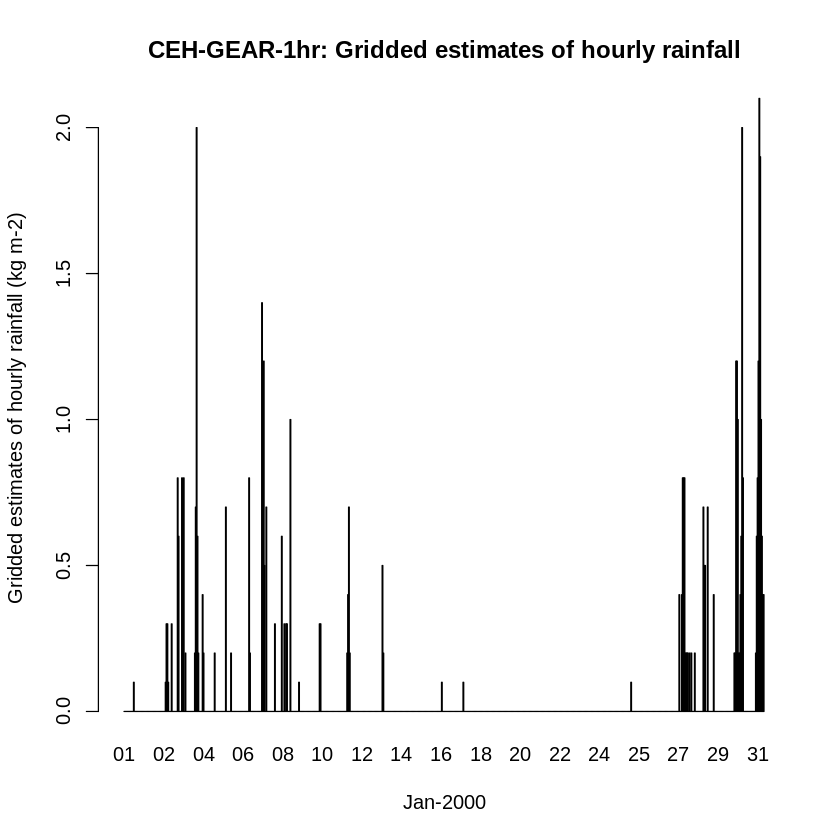

In [32]:
units    <- ncatt_get(nc, "rainfall_amount", "units")$value
longname <- ncatt_get(nc, "rainfall_amount", "long_name")$value

barplot(
  ts_df$rainfall_mm,
  names.arg = format(ts_df$date, "%d"),
  col  = "#1d6fa4",
  main = paste("CEH-GEAR-1hr:", longname),
  xlab = format(datetimes[1], "%b-%Y"),
  ylab = paste0(longname, " (", units, ")"),
)

---
## 5. Map at a single time step

Read the full 2-D spatial grid for the first time step (Jan 1st 2000 00:00) and plot it.

In [34]:
# Read spatial slice for the first time step
# start = [all_x, all_y, time_step_1], count = [all, all, 1]
t_index <- 1
grid <- ncvar_get(
  nc, "rainfall_amount",
  start = c(1, 1, t_index),
  count = c(-1, -1, 1)        # -1 means read all
)

cat(sprintf("Grid dimensions: %d x (easting) × %d y (northing)\n", dim(grid)[1], dim(grid)[2]))

Grid dimensions: 701 x (easting) × 1251 y (northing)


In [40]:
# The grid from ncvar_get is [x, y] — we transpose it to [y, x] for image()
# and flip y so north is at the top (y increases downward in ncvar_get output)
grid_plot <- grid[nrow(grid):1, ]

# Colour palette: white → blue
rain_cols <- colorRampPalette(c("white", "#c6dbef", "#4393c3", "#08306b"))(100)

image(
  x = x / 1000,     # convert metres to km for cleaner axis labels
  y = rev(y) / 1000,
  z = grid_plot,
  col  = rain_cols,
  xlab = "Easting (km)",
  ylab = "Northing (km)",
  main = paste0("CEH-GEAR-1hr: ", longname, "\n", format(dates[t_index], "%B %Y"))
)

# Simple colourbar using legend
legend("bottomright",
  legend = round(seq(min(grid, na.rm=TRUE), max(grid, na.rm=TRUE), length.out = 5)),
  fill   = rain_cols[c(1, 25, 50, 75, 100)],
  title  = units, bty = "n", cex = 0.8
)

ERROR: Error in parse(text = input): <text>:3:14: unexpected '['
2: # and flip y so north is at the top (y increases downward in ncvar_get output)
3: grid_plot <- [
                ^


## Appendix

### Quarto rendering

To render as a standalone HTML report:
```bash
quarto render gear_netcdf_r.ipynb --to html
```
Or convert to `.qmd` first:
```bash
quarto convert gear_netcdf_r.ipynb
```
---

**Data citation:** CEH-GEAR, UKCEH. https://doi.org/10.5285/dbf13dd5-90cd-457a-a986-f2f9dd97e93c